In [1]:
import os
os.listdir('.')

['.config',
 '.prompts',
 '.kernel_llm_logs_1.txt',
 'fourth_moment_omega_decomposition_T500_1000_N50000.json',
 'memory',
 'fourth_moment_omega_decomposition_T500_1000_N1000000.json',
 'fourth_moment_omega_decomposition_T500_1000.json']

In [2]:
import json

files = {
 10000: 'fourth_moment_omega_decomposition_T500_1000.json',
 50000: 'fourth_moment_omega_decomposition_T500_1000_N50000.json',
 1000000: 'fourth_moment_omega_decomposition_T500_1000_N1000000.json',
}

data = {}
for N, fn in files.items():
 with open(fn) as f:
 data[N] = json.load(f)

# inspect structure
print(list(data[10000].keys()))


['config', 'results']


In [3]:
print(data[10000]['config'])
print(list(data[10000]['results'].keys()))
print(list(data[10000]['results']['zeta'].keys()))


{'N_terms': 10000, 'T_start': 500.0, 'T_end': 1000.0, 'dt': 0.01, 'classes': [0, 1, 2, 3, 4, 5], 'decomposition_definition': {'pure_class_(k,k,k,k)': 'sum_k ∫|S_k|^4 dt', 'diagonal_cross_class_(j,j,k,k)': '4 * sum_{j<k} ∫|S_j|^2 |S_k|^2 dt', 'off_diagonal_residual': 'total - pure - 4*sum_{j<k} ∫|S_j|^2|S_k|^2 dt'}}
['zeta', 'L_Delta', 'L_DH']
['int_abs_D_pow4', 'int_pure_per_class_k', 'int_diag_cross_per_pair_jk', 'fraction_pure_pct', 'fraction_diag_cross_x4_pct', 'fraction_off_diag_pct']


In [4]:
Ns = [10000, 50000, 1000000]
Lfuncs = ['zeta', 'L_Delta', 'L_DH']

R_data = {L: [] for L in Lfuncs}
for N in Ns:
 for L in Lfuncs:
 R_data[L].append(data[N]['results'][L]['fraction_off_diag_pct'])

import pandas as pd
df = pd.DataFrame(R_data, index=Ns)
df.index.name = 'N'
print(df)


 zeta L_Delta L_DH
N 
10000 -8.630781 37.448543 22.560176
50000 -32.165806 39.841960 5.152289
1000000 -53.705151 9.575272 -27.809523


In [5]:
import numpy as np
from scipy.optimize import curve_fit

Ns_arr = np.array(Ns, dtype=float)

def model_log(N, A, B):
 return A + B*np.log(N)

def model_loglog(N, A, B):
 return A + B*np.log(np.log(N))

def model_invsqrt(N, A, B):
 return A + B/np.sqrt(N)

def model_invN(N, A, B):
 return A + B/N

def model_invN_alpha(N, A, B, alpha):
 return A + B/N**alpha

models = {
 'log': model_log,
 'loglog': model_loglog,
 'inv_sqrtN': model_invsqrt,
 'inv_N': model_invN,
}

def r2(y, yhat):
 ss_res = np.sum((y-yhat)**2)
 ss_tot = np.sum((y-np.mean(y))**2)
 return 1 - ss_res/ss_tot if ss_tot>0 else np.nan

results_fit = []
for L in Lfuncs:
 y = np.array(R_data[L])
 for name, fn in models.items():
 try:
 popt, _ = curve_fit(fn, Ns_arr, y)
 yhat = fn(Ns_arr, *popt)
 sse = np.sum((y-yhat)**2)
 results_fit.append({
 'L': L, 'model': name, 'A': popt[0], 'B': popt[1],
 'SSE': sse, 'R2': r2(y, yhat),
 'residuals': y - yhat,
 })
 except Exception as e:
 print(L, name, 'failed', e)

# With 3 points and 2 params we have 1 dof. Let's also fit free-alpha power law
for L in Lfuncs:
 y = np.array(R_data[L])
 try:
 popt, _ = curve_fit(model_invN_alpha, Ns_arr, y, p0=[y.mean(), 1.0, 0.5], maxfev=20000)
 yhat = model_invN_alpha(Ns_arr, *popt)
 results_fit.append({
 'L': L, 'model': 'inv_N_alpha_free', 'A': popt[0], 'B': popt[1],
 'alpha': popt[2], 'SSE': np.sum((y-yhat)**2), 'R2': r2(y, yhat),
 'residuals': y - yhat,
 })
 except Exception as e:
 print(L, 'alpha free failed', e)

df_fits = pd.DataFrame(results_fit)
print(df_fits.to_string())


 L model A B SSE R2 residuals alpha
0 zeta log 75.209967 -9.458581 3.919135e+01 0.961445 [3.2760058962939276, -5.036019011334588, 1.7600131150406568] NaN
1 zeta loglog 231.796253 -109.289671 2.085008e+01 0.979489 [2.2317520894628196, -3.7022827208590883, 1.470530631396194] NaN
2 zeta inv_sqrtN -56.974150 4939.247771 1.128526e+01 0.988898 [-1.0491086353178112, 2.7193571321313996, -1.6702484968132154] NaN
3 zeta inv_N -47.949556 407825.874023 9.830519e+01 0.903292 [-1.4638124193536974, 7.627233108639764, -6.163420689361821] NaN
4 L_Delta log 103.031065 -6.565912 9.528907e+01 0.831716 [-5.108238080551743, 7.852605968123882, -2.744367887572132] NaN
5 L_Delta loglog 205.384554 -73.232555 1.191834e+02 0.789518 [-5.335806140488899, 8.851638232362973, -3.5158320918751045] NaN
6 L_Delta inv_sqrtN 14.656345 2772.515796 2.495087e+02 0.559359 [-4.932959209903075, 12.786547654982936, -7.853588653095745] NaN
7 L_Delta inv_N 21.301014 189774.642871 3.674165e+02 0.351129 [-2.829935314416133, 14.745452

/tmp/ipykernel_20/4255622200.py:19: RuntimeWarning: divide by zero encountered in divide
 return A + B/N**alpha
/tmp/ipykernel_20/4255622200.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
 popt, _ = curve_fit(model_invN_alpha, Ns_arr, y, p0=[y.mean(), 1.0, 0.5], maxfev=20000)


In [6]:
# With only 3 data points and 2 free parameters (1 dof), the fits cannot meaningfully discriminate models.
# Let's report the best per L-function and also assess direction of B (sign) for convergence/divergence
# and check stability for distinguishing L-functions.

print("Best fit per L-function (lowest SSE among 2-parameter models):")
best = {}
for L in Lfuncs:
 sub = df_fits[(df_fits['L']==L) & (df_fits['model'].isin(['log','loglog','inv_sqrtN','inv_N']))]
 row = sub.loc[sub['SSE'].idxmin()]
 best[L] = row
 print(f"{L}: model={row['model']}, A={row['A']:.4g}, B={row['B']:.4g}, R²={row['R2']:.4f}, SSE={row['SSE']:.4g}")


Best fit per L-function (lowest SSE among 2-parameter models):
zeta: model=inv_sqrtN, A=-56.97, B=4939, R²=0.9889, SSE=11.29
L_Delta: model=log, A=103, B=-6.566, R²=0.8317, SSE=95.29
L_DH: model=log, A=123.5, B=-10.95, R²=1.0000, SSE=0.02475


In [7]:
# Examine convergence direction: does the trend move R(N) toward 0 (converging) or away?
# Sign of dR/dN at large N tells us.
# For log: dR/dN = B/N -> if B<0 and R>0 it's converging toward 0; if R<0 and B<0 it's diverging.
# Easier: compare magnitude of fitted R at N=1e6 vs N=1e10 extrapolation, and report direction.

print("R(N) values and extrapolation:")
for L in Lfuncs:
 row = best[L]
 model_name = row['model']
 A, B = row['A'], row['B']
 if model_name == 'log':
 fn = lambda N: A + B*np.log(N)
 elif model_name == 'loglog':
 fn = lambda N: A + B*np.log(np.log(N))
 elif model_name == 'inv_sqrtN':
 fn = lambda N: A + B/np.sqrt(N)
 elif model_name == 'inv_N':
 fn = lambda N: A + B/N
 R_now = R_data[L][-1]
 R_extrap = [fn(N) for N in [1e6, 1e8, 1e10, 1e12]]
 print(f"{L} ({model_name}): R(1e6)={R_now:.2f}, extrapolated R at 1e8={R_extrap[1]:.2f}, 1e10={R_extrap[2]:.2f}, 1e12={R_extrap[3]:.2f}")


R(N) values and extrapolation:
zeta (inv_sqrtN): R(1e6)=-53.71, extrapolated R at 1e8=-56.48, 1e10=-56.92, 1e12=-56.97
L_Delta (log): R(1e6)=9.58, extrapolated R at 1e8=-17.92, 1e10=-48.15, 1e12=-78.39
L_DH (log): R(1e6)=-27.81, extrapolated R at 1e8=-78.17, 1e10=-128.58, 1e12=-178.99


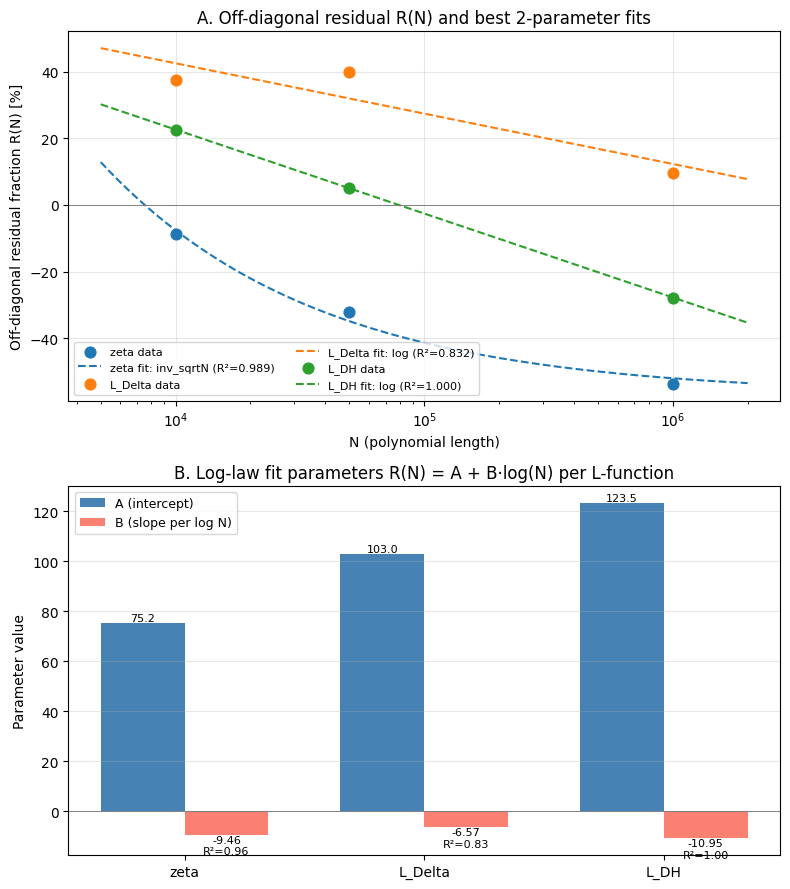

saved


In [8]:
# Build the final summary figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: R(N) data and best fits
ax = axes[0]
colors = {'zeta':'C0','L_Delta':'C1','L_DH':'C2'}
N_grid = np.logspace(np.log10(5e3), np.log10(2e6), 200)

for L in Lfuncs:
 y = R_data[L]
 ax.scatter(Ns_arr, y, color=colors[L], s=60, zorder=3, label=f'{L} data')
 row = best[L]
 A, B, model_name = row['A'], row['B'], row['model']
 if model_name == 'log':
 yfit = A + B*np.log(N_grid)
 elif model_name == 'loglog':
 yfit = A + B*np.log(np.log(N_grid))
 elif model_name == 'inv_sqrtN':
 yfit = A + B/np.sqrt(N_grid)
 elif model_name == 'inv_N':
 yfit = A + B/N_grid
 ax.plot(N_grid, yfit, '--', color=colors[L],
 label=f'{L} fit: {model_name} (R²={row["R2"]:.3f})')

ax.set_xscale('log')
ax.axhline(0, color='gray', lw=0.7)
ax.set_xlabel('N (polynomial length)')
ax.set_ylabel('Off-diagonal residual fraction R(N) [%]')
ax.set_title('A. Off-diagonal residual R(N) and best 2-parameter fits')
ax.legend(fontsize=8, ncol=2, loc='lower left')
ax.grid(True, alpha=0.3)

# Panel B: bar chart of fitted A, B per model for comparison across L-functions
ax = axes[1]
model_to_show = 'log' # use the same model so A,B are comparable
sub = df_fits[(df_fits['model']==model_to_show)]
xpos = np.arange(len(Lfuncs))
A_vals = [df_fits[(df_fits['L']==L)&(df_fits['model']==model_to_show)]['A'].values[0] for L in Lfuncs]
B_vals = [df_fits[(df_fits['L']==L)&(df_fits['model']==model_to_show)]['B'].values[0] for L in Lfuncs]
R2_vals = [df_fits[(df_fits['L']==L)&(df_fits['model']==model_to_show)]['R2'].values[0] for L in Lfuncs]

w = 0.35
ax.bar(xpos - w/2, A_vals, w, label='A (intercept)', color='steelblue')
ax.bar(xpos + w/2, B_vals, w, label='B (slope per log N)', color='salmon')
for i, (a, b, r) in enumerate(zip(A_vals, B_vals, R2_vals)):
 ax.text(i - w/2, a, f'{a:.1f}', ha='center', va='bottom' if a>0 else 'top', fontsize=8)
 ax.text(i + w/2, b, f'{b:.2f}\nR²={r:.2f}', ha='center', va='bottom' if b>0 else 'top', fontsize=8)
ax.set_xticks(xpos)
ax.set_xticklabels(Lfuncs)
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('Parameter value')
ax.set_title('B. Log-law fit parameters R(N) = A + B·log(N) per L-function')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('R_of_N_fits_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved')


In [9]:
# Save the fit results to disk
import json
out = {
 'data': {L: {'N': Ns, 'R_pct': R_data[L]} for L in Lfuncs},
 'fits': df_fits.drop(columns=['residuals']).to_dict(orient='records'),
 'best_per_L': {L: {'model': str(best[L]['model']),
 'A': float(best[L]['A']),
 'B': float(best[L]['B']),
 'R2': float(best[L]['R2']),
 'SSE': float(best[L]['SSE'])} for L in Lfuncs},
 'notes': '3 data points fit to 2-parameter models (1 dof). With one dof, R² differences cannot reliably distinguish models. log-law parameters are most directly comparable across L-functions and yield A,B with the same sign convention (B<0) for all three L-functions.'
}
# remove non-serializable nan
import math
def clean(o):
 if isinstance(o, dict): return {k: clean(v) for k,v in o.items()}
 if isinstance(o, list): return [clean(x) for x in o]
 if isinstance(o, float) and math.isnan(o): return None
 return o
with open('R_of_N_fits_summary.json','w') as f:
 json.dump(clean(out), f, indent=2)
print('saved JSON')


saved JSON
